<a href="https://colab.research.google.com/github/divyaaarumugam5-design/ml-leakage-pipeline-divyaa/blob/main/Regression_prediction_Assigment_Divyaa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
print("Successfully imported")




Successfully imported


Task 1

Create a synthetic dataset with at least 50 records containing these features: area_sqft, num_bedrooms, age_years, and a target column price_lakhs. Build a multiple linear regression model using scikit-learn, print the intercept and each feature's coefficient, and display the first five actual vs. predicted values.

In [16]:
# House price dataset (prices in lakhs)
np.random.seed(42)
n = 50

area_sqft    = np.random.randint(600, 2500, n)
num_bedrooms = np.random.randint(1, 6, n)
age_years    = np.random.randint(0, 21, n)
# Just randomly defining price per area/bedrooms/age_years....

price_lakhs = 0.04 * area_sqft + 8 * num_bedrooms - 0.5 * age_years + 10

houses=pd.DataFrame({'area_sqft':area_sqft, 'num_bedrooms':num_bedrooms, 'age_years':age_years,'price_lakhs':price_lakhs.round(2)})

# print(houses.head())

# Features and Target

X=houses[['area_sqft','num_bedrooms','age_years']]
y=houses['price_lakhs']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)

print("Intercept:",model.intercept_)
print("Coefficients of each features:",model.coef_)

y_prediction=model.predict(X_test)
print("Preditions:",y_prediction)

#Actual vs Prediction

result=pd.DataFrame({"actual_value":y_test,"predicted_value":y_prediction})
print(result.head())


Intercept: 9.999999999999432
Coefficients of each features: [ 0.04  8.   -0.5 ]
Preditions: [105.78  84.96  55.54  82.   106.84  95.28  98.2   98.98  91.36  68.2 ]
    actual_value  predicted_value
13        105.78           105.78
39         84.96            84.96
30         55.54            55.54
45         82.00            82.00
17        106.84           106.84


Task 2

Evaluate your model using MAE, RMSE, and R². Print all three metrics. Then write a comment in your code (2–3 lines) explaining what each metric value tells you about your model's performance.

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae=mean_absolute_error(y_test,y_prediction)
rmse=np.sqrt(mean_squared_error(y_test,y_prediction))
r2=r2_score(y_test,y_prediction)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

#Comments:

# MAE shows the average absolute difference between actual and predicted values.
# RMSE is root mean squared error shows bigger difference for large erroes
# R2 score indicates how well the model explains the variance which is if the value is closer to 1 it is better fit


MAE: 1.4352963262354023e-13
RMSE: 1.7549111014472584e-13
R2 Score: 1.0


Task 3

Compute the residuals for all predictions. Plot a histogram of residuals using Matplotlib. Add a title and axis labels. Below the plot, write a markdown cell (or a comment) explaining what a residual is and what the shape of your histogram suggests about your model.

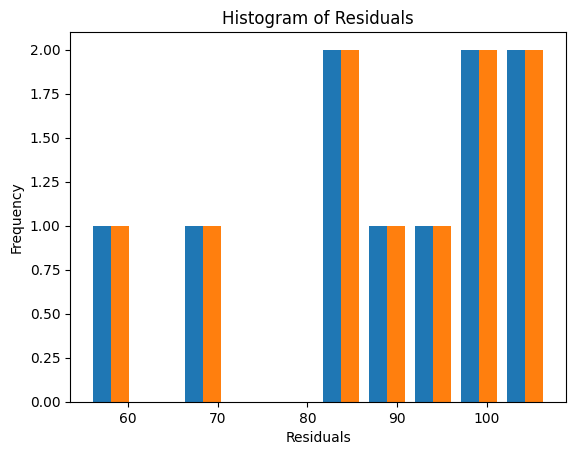

In [20]:
import matplotlib.pyplot as plt
residuals=y_test,y_prediction
plt.hist(residuals, bins=10)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


# Comments:
# Residual is difference between actual - predicted values, from the below histogram we can see residuals are not skewed , model is perfomring well for this small dataset
